In [ ]:
!kaggle datasets download -d anshtanwar/global-data-on-sustainable-energy
!unzip global-data-on-sustainable-energy.zip

Dataset URL: https://www.kaggle.com/datasets/anshtanwar/global-data-on-sustainable-energy
License(s): Attribution 4.0 International (CC BY 4.0)
global-data-on-sustainable-energy.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  global-data-on-sustainable-energy.zip
replace global-data-on-sustainable-energy (1).csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: global-data-on-sustainable-energy (1).csv  


##1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

## 2. Exploratory Data Analysis (EDA)

### 2.1 Load Dataset

In [ ]:
df_raw = pd.read_csv('global-data-on-sustainable-energy (1).csv')
print(f'Shape raw: {df_raw.shape}')
print(f'Jumlah negara unik: {df_raw["Entity"].nunique()}')
print(f'Rentang tahun: {df_raw["Year"].min()} - {df_raw["Year"].max()}')
df_raw.head()

Shape raw: (3649, 21)
Jumlah negara unik: 176
Rentang tahun: 2000 - 2020


,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.93911,67.709953


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   object 
 1   Year                                                              3649 non-null   int64  
 2   Access to electricity (% of population)                           3639 non-null   float64
 3   Access to clean fuels for cooking                                 3480 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              2718 non-null   float64
 5   Financial flows to developing countries (US $)                    1560 non-null   float64
 6   Renewable energy share in the total final energy consumption (%)  3455 non-null   float64
 7   Electricity from fossil fuels (TW

### 2.2 Agregasi Per Negara

Karena tujuannya mengklasifikasikan negara (bukan per tahun), data diagregasi dengan mengambil rata-rata 3 tahun terakhir per negara. Ini dilakukan agar memastikan setiap negara hanya punya 1 baris.

In [ ]:
kolom_numerik = df_raw.select_dtypes(include='number').columns.tolist()
aturan_agg = {kolom: 'mean' for kolom in kolom_numerik}
aturan_agg["Density\\n(P/Km2)"] = 'first'

df = (df_raw.sort_values('Year')
      .groupby('Entity')
      .tail(3)
      .groupby('Entity')
      .agg(aturan_agg)
      .reset_index()
)
print(f'Shape setelah agregasi: {df.shape}')
df.head()

Shape setelah agregasi: (176, 21)


,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Land Area(Km2),Latitude,Longitude,Density\n(P/Km2)
0,Afghanistan,2019.0,97.338712,32.000000,9.493333,37360000.0,18.235,0.166667,0.0,0.846667,...,809.917133,2.425,6075.000048,NaN,0.916577,498.865213,652230.0,33.939110,67.709953,60
1,Albania,2019.0,100.000000,80.600000,NaN,NaN,NaN,0.000000,0.0,6.316667,...,12451.086333,2.535,4970.000029,NaN,0.725794,5309.871844,28748.0,41.153332,20.168331,105
2,Algeria,2019.0,99.667323,99.666667,15.940000,55000.0,0.175,73.060000,0.0,0.780000,...,15721.314667,5.255,168394.996650,0.293442,-1.000000,3812.848347,2381741.0,28.033886,1.659626,18
3,Angola,2019.0,45.941137,49.600000,108.530000,90000.0,56.025,3.933333,0.0,11.006667,...,3520.325700,2.945,24584.999080,NaN,-2.676087,2625.145650,1246700.0,-11.202692,17.873887,26
4,Antigua and Barbuda,2019.0,100.000000,100.000000,113.220000,NaN,0.905,0.320000,0.0,0.013333,...,31279.656667,3.510,514.999986,NaN,-2.815498,16016.328607,443.0,17.060816,-61.796428,223


### 2.3 Struktur Data

In [ ]:
df.info()
print(f'Jumlah negara: {df["Entity"].nunique()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 20 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            176 non-null    object 
 1   Year                                                              176 non-null    float64
 2   Access to electricity (% of population)                           175 non-null    float64
 3   Access to clean fuels for cooking                                 167 non-null    float64
 4   Renewable-electricity-generating-capacity-per-capita              131 non-null    float64
 5   Financial flows to developing countries (US $)                    98 non-null     float64
 6   Renewable energy share in the total final energy consumption (%)  175 non-null    float64
 7   Electricity from fossil fuels (TWh)

### 2.4 Statistik Deskriptif

In [ ]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Year,176.0,2.018890e+03,1.430000e+00,2000.00,2019.00,2019.00,2019.00,2.019000e+03
Access to electricity (% of population),175.0,8.485000e+01,2.503000e+01,6.71,72.08,99.77,100.00,1.000000e+02
Access to clean fuels for cooking,167.0,6.718000e+01,3.777000e+01,0.00,32.38,87.50,100.00,1.000000e+02
Renewable-electricity-generating-capacity-per-capita,131.0,1.654200e+02,3.145500e+02,0.06,15.05,66.10,170.23,2.742550e+03
Financial flows to developing countries (US $),98.0,1.101448e+08,2.116274e+08,10000.00,6621250.00,32330000.00,87815000.00,1.275230e+09
Renewable energy share in the total final energy consumption (%),175.0,3.135000e+01,2.768000e+01,0.00,8.62,23.83,49.89,9.498000e+01
Electricity from fossil fuels (TWh),175.0,8.389000e+01,4.425800e+02,0.00,0.44,3.50,29.35,5.090880e+03
Electricity from nuclear (TWh),170.0,1.344000e+01,7.368000e+01,0.00,0.00,0.00,0.00,8.021200e+02
Electricity from renewables (TWh),175.0,3.757000e+01,1.720700e+02,0.00,0.19,2.41,14.11,2.011610e+03
Low-carbon electricity (% electricity),174.0,3.924000e+01,3.317000e+01,0.00,9.73,31.70,65.12,1.000000e+02


### 2.5 Analisis Missing Value

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
missing_df = missing_df[missing_df['Jumlah Missing'] > 0].sort_values('Persentase (%)', ascending=False)
print(f'Kolom dengan missing value: {len(missing_df)}')
missing_df

Kolom dengan missing value: 17


,Jumlah Missing,Persentase (%)
Renewables (% equivalent primary energy),104,59.09
Financial flows to developing countries (US $),78,44.32
Renewable-electricity-generating-capacity-per-capita,45,25.57
Value_co2_emissions_kt_by_country,17,9.66
gdp_growth,16,9.09
gdp_per_capita,14,7.95
Access to clean fuels for cooking,9,5.11
Electricity from nuclear (TWh),6,3.41
Energy intensity level of primary energy (MJ/$2017 PPP GDP),5,2.84
Low-carbon electricity (% electricity),2,1.14


### 2.6 Tren Global Per Tahun

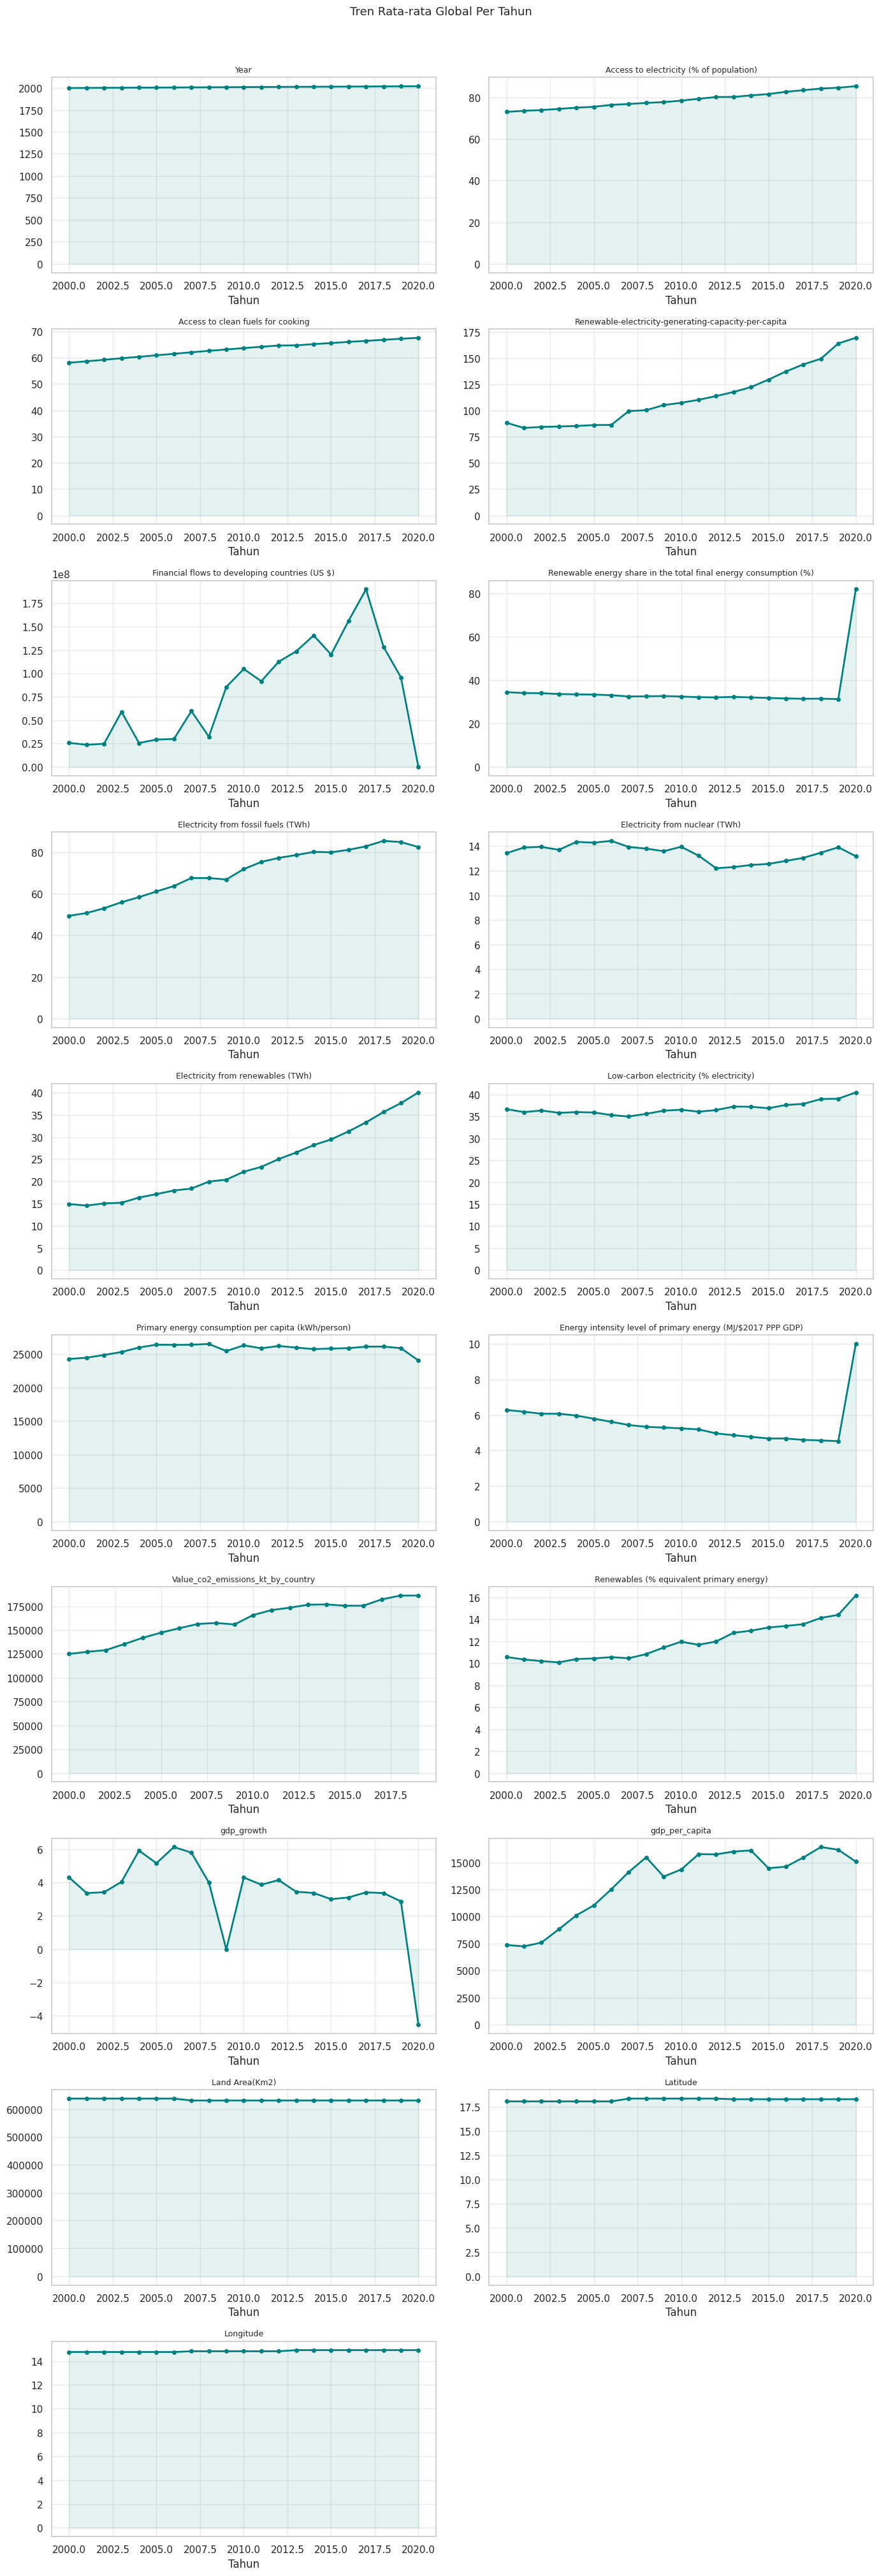

In [ ]:
features_trend = df_raw.select_dtypes(include='number').columns.tolist()

df_trend = df_raw.groupby('Year')[features_trend].mean()

n_cols = 2
n_rows = (len(features_trend) + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(features_trend):
    axes[i].plot(df_trend.index, df_trend[col], marker='o', color='teal', linewidth=2, markersize=4)
    axes[i].fill_between(df_trend.index, df_trend[col], alpha=0.1, color='teal')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Tahun')
    axes[i].grid(True, alpha=0.4)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Tren Rata-rata Global Per Tahun', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 2.7 Boxplot & Deteksi Outlier

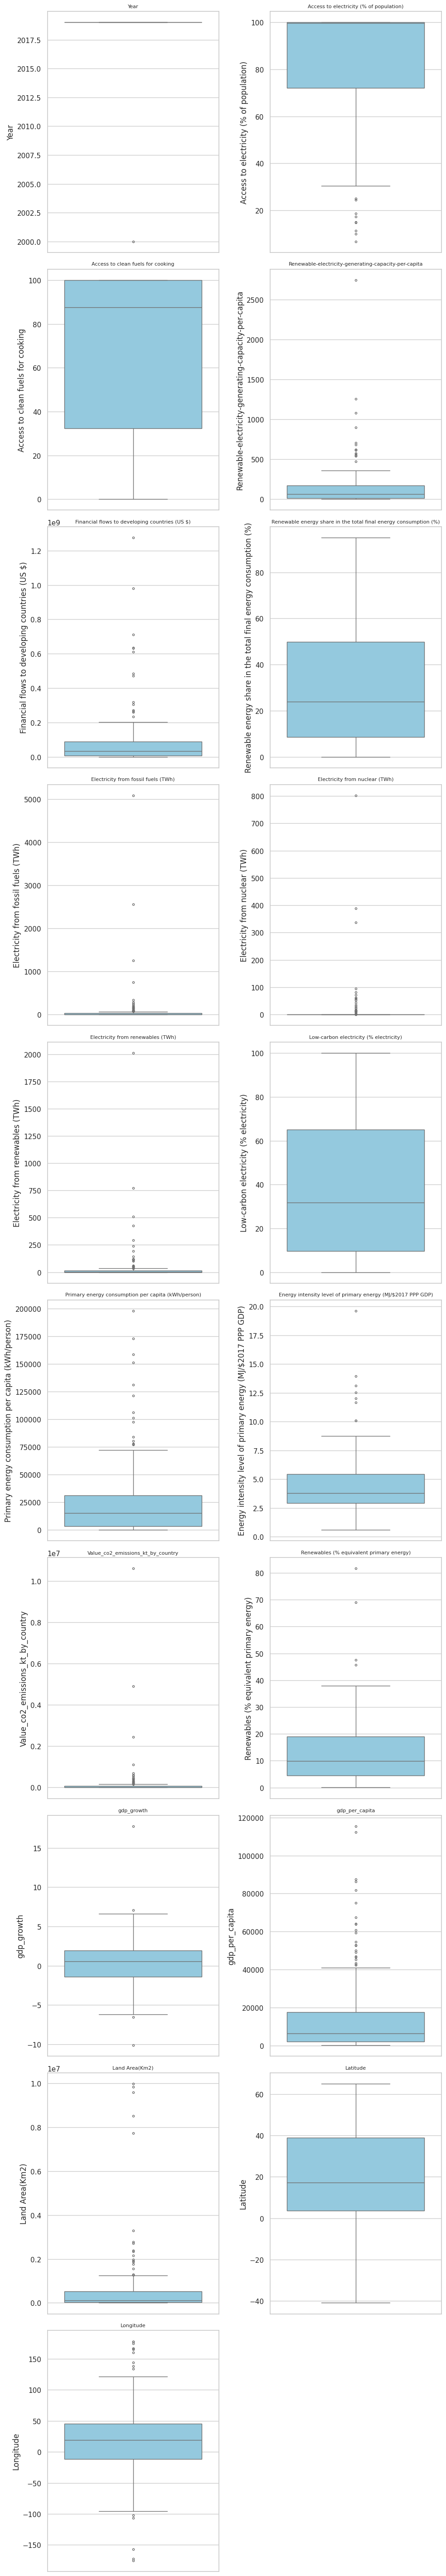


Outlier (IQR)
Year: 1 outlier (0.6%)
Access to electricity (% of population): 9 outlier (5.1%)
Renewable-electricity-generating-capacity-per-capita: 15 outlier (8.5%)
Financial flows to developing countries (US $): 14 outlier (8.0%)
Electricity from fossil fuels (TWh): 29 outlier (16.5%)
Electricity from nuclear (TWh): 29 outlier (16.5%)
Electricity from renewables (TWh): 24 outlier (13.6%)
Primary energy consumption per capita (kWh/person): 14 outlier (8.0%)
Energy intensity level of primary energy (MJ/$2017 PPP GDP): 8 outlier (4.5%)
Value_co2_emissions_kt_by_country: 24 outlier (13.6%)
Renewables (% equivalent primary energy): 4 outlier (2.3%)
gdp_growth: 4 outlier (2.3%)
gdp_per_capita: 22 outlier (12.5%)
Land Area(Km2): 19 outlier (10.8%)
Longitude: 15 outlier (8.5%)


In [ ]:
cols_number = df.select_dtypes(include=['number']).columns
cols_to_plot = [c for c in cols_number if not df[c].isnull().all()]

n_rows = (len(cols_to_plot) // 2) + (len(cols_to_plot) % 2)
fig, axes = plt.subplots(nrows=n_rows, ncols=2, figsize=(10, 3 * len(cols_to_plot)))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue', flierprops=dict(marker='o', markersize=3))
    axes[i].set_title(col, fontsize=8)

for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print('\nOutlier (IQR)')
for col in cols_to_plot:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    if n > 0:
        print(f'{col}: {n} outlier ({n/len(df)*100:.1f}%)')

### 2.8 Distribusi Fitur

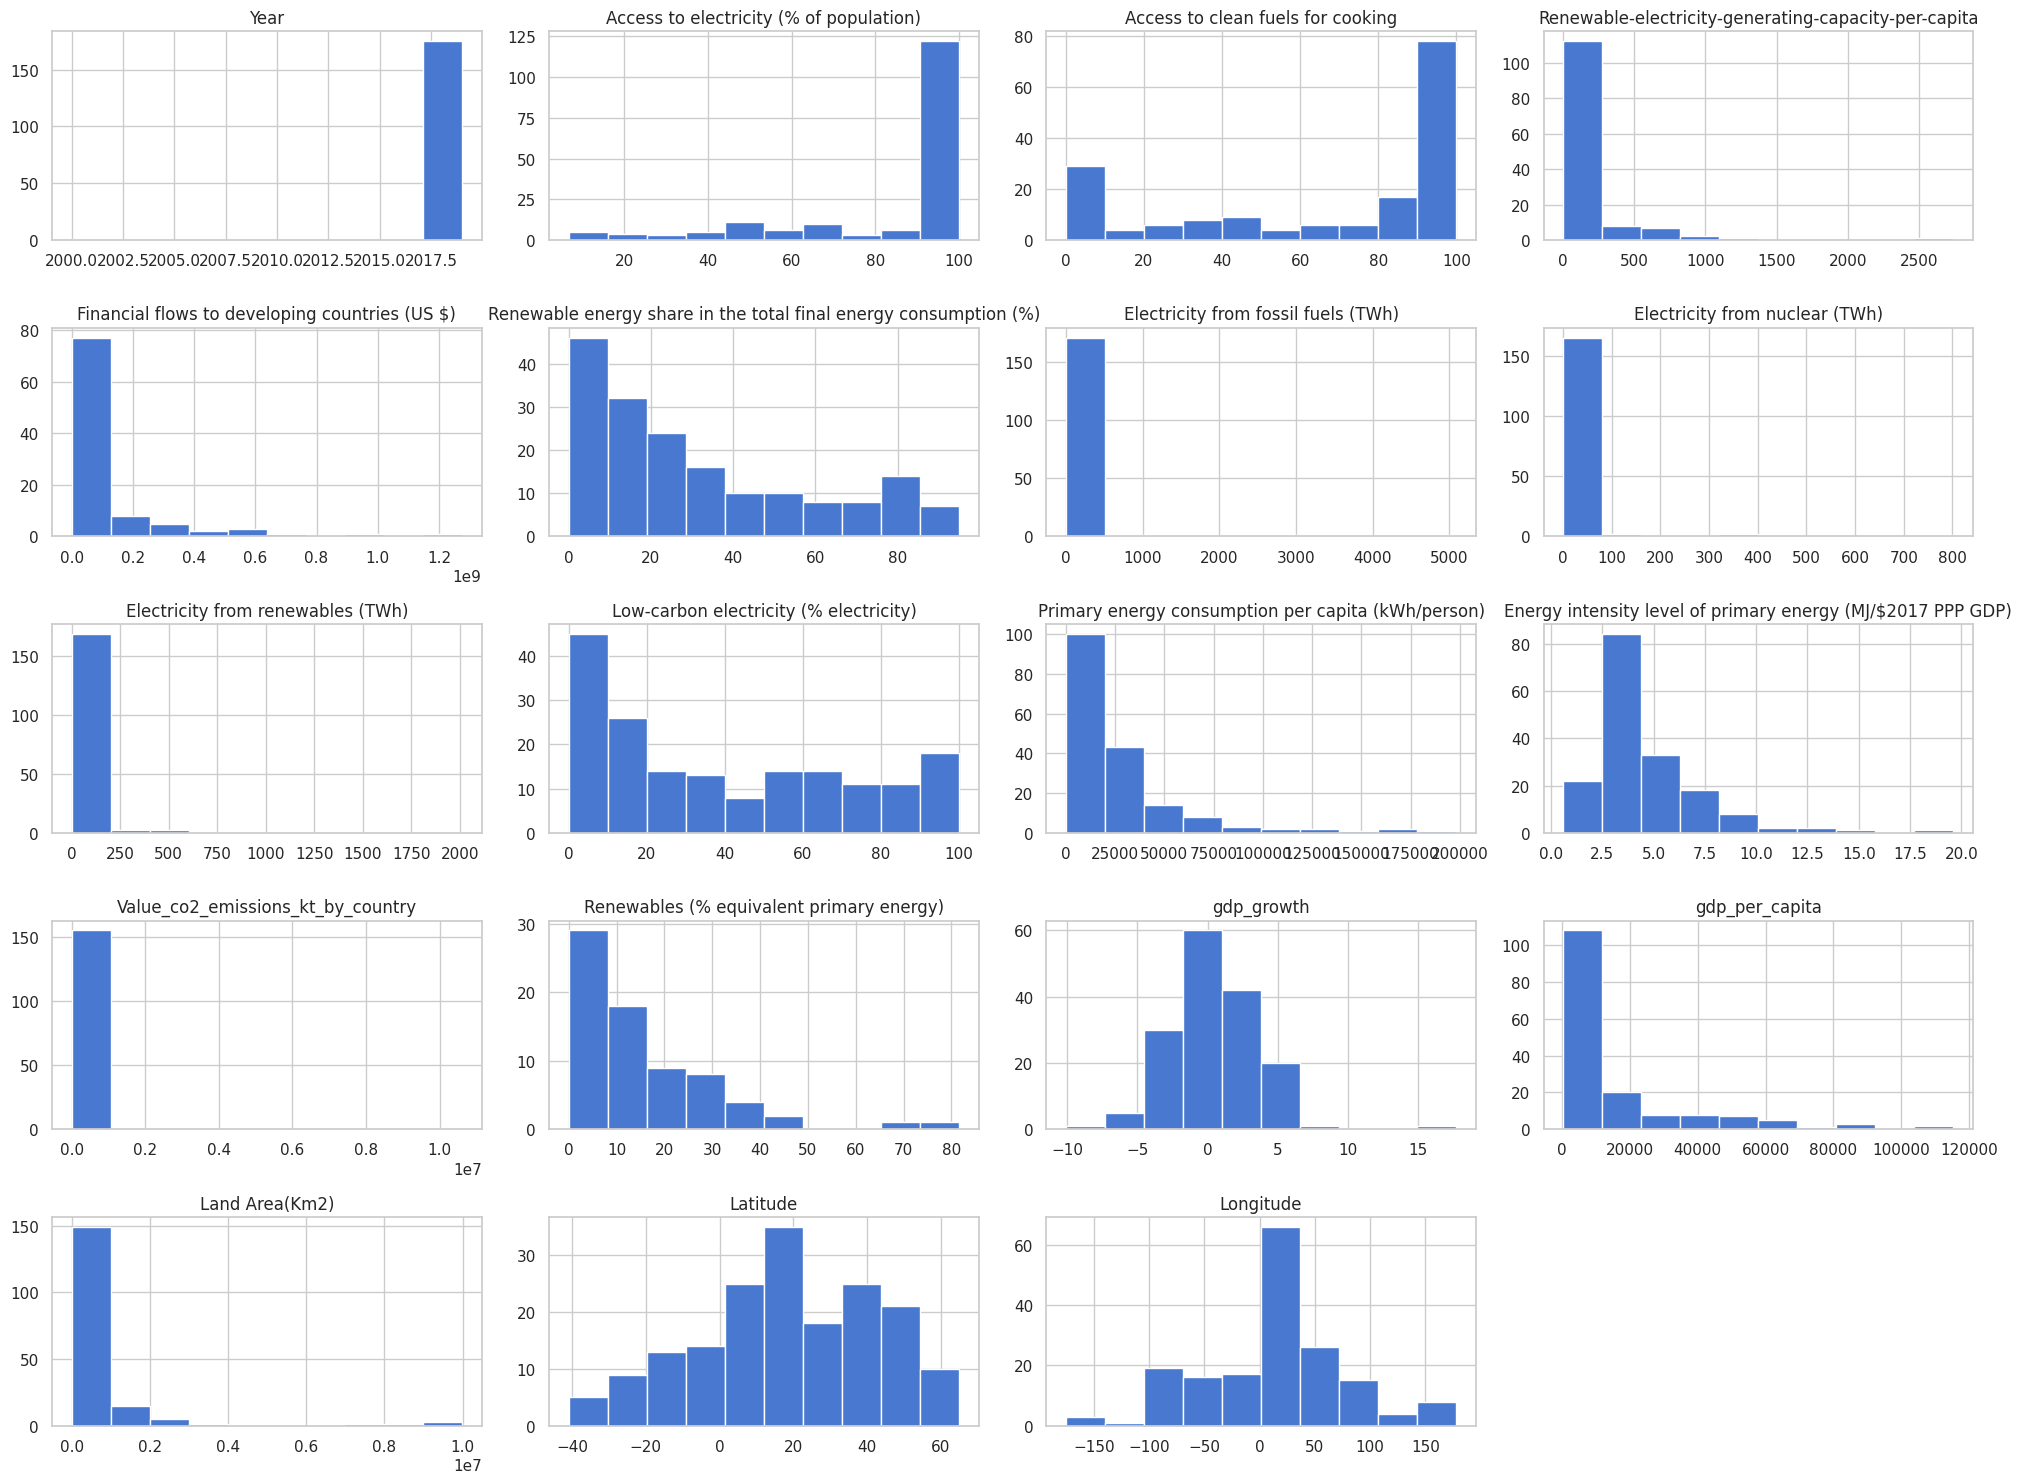

Kolom dengan skewness tinggi (|skew| > 1):
  Year: -13.27
  Access to electricity (% of population): -1.56
  Renewable-electricity-generating-capacity-per-capita: 5.08
  Financial flows to developing countries (US $): 3.27
  Electricity from fossil fuels (TWh): 9.56
  Electricity from nuclear (TWh): 8.66
  Electricity from renewables (TWh): 9.45
  Primary energy consumption per capita (kWh/person): 2.63
  Energy intensity level of primary energy (MJ/$2017 PPP GDP): 2.20
  Value_co2_emissions_kt_by_country: 9.45
  Renewables (% equivalent primary energy): 1.99
  gdp_per_capita: 2.19
  Land Area(Km2): 4.69


In [ ]:
df.hist(figsize=(20, 15))
plt.tight_layout()
plt.show()

print('Kolom dengan skewness tinggi (|skew| > 1):')
for col in cols_to_plot:
    s = df[col].skew()
    if abs(s) > 1:
        print(f'  {col}: {s:.2f}')

### 2.9 Heatmap Correlation Semua fitur

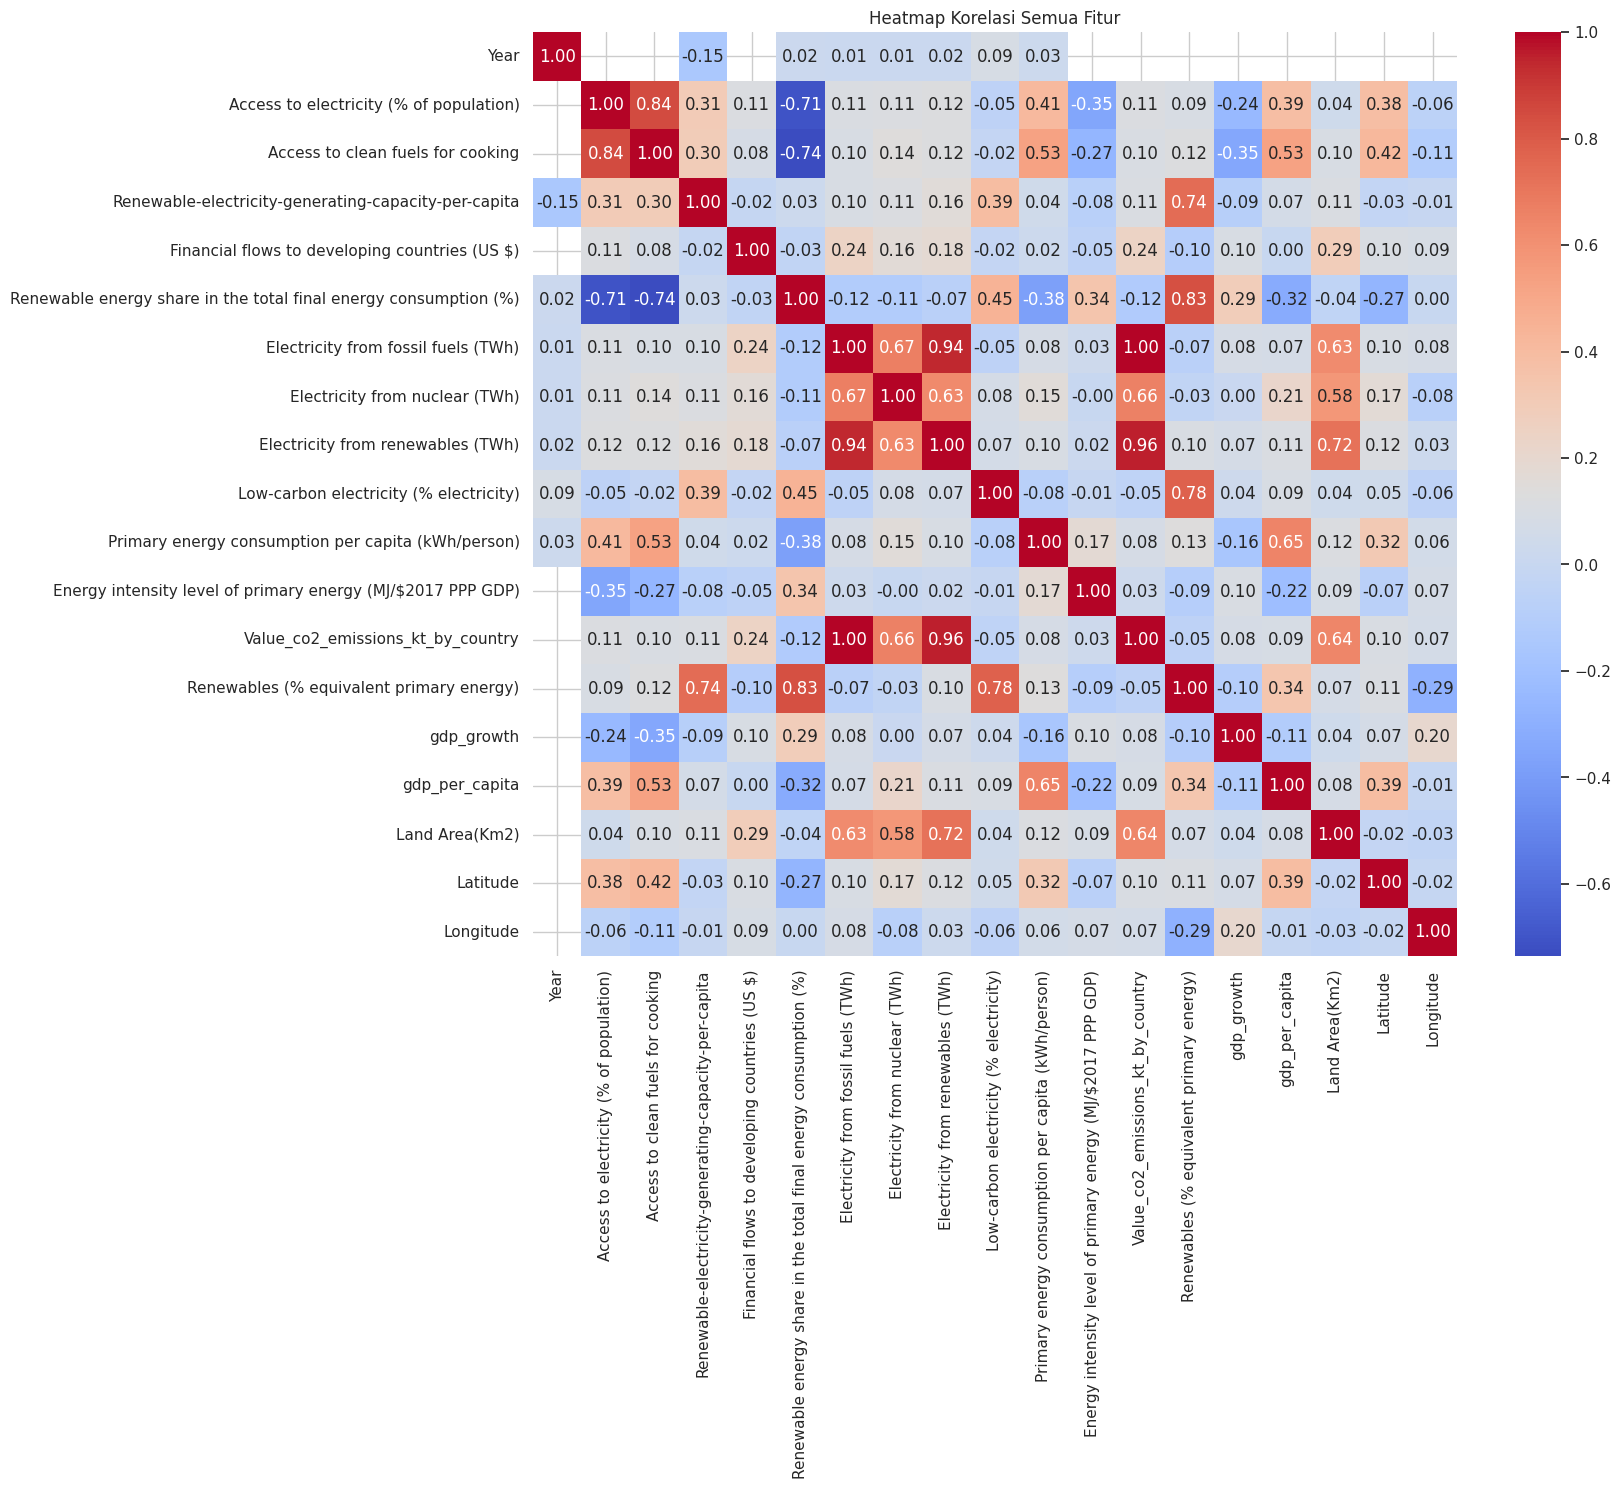

In [ ]:
plt.figure(figsize=(15, 12))
sns.heatmap(df.corr(numeric_only=True),
             annot=True,
            fmt='.2f',
            square=True,
            cmap='coolwarm',)
plt.title('Heatmap Korelasi Semua Fitur')
plt.show()

## 3. Feature Engineering

Dipilih 5 fitur utama yang merepresentasikan dimensi sustainability energi secara komprehensif:

| Fitur | Dimensi |
|---|---|
| Access to electricity | Aksesibilitas energi |
| Renewable energy share | Porsi energi terbarukan |
| Low-carbon electricity | Kebersihan listrik |
| Primary energy consumption per capita | Konsumsi energi per orang |
| Energy intensity | Efisiensi ekonomi-energi |

In [ ]:
features = [
    'Access to electricity (% of population)',
    'Renewable energy share in the total final energy consumption (%)',
    'Low-carbon electricity (% electricity)',
    'Primary energy consumption per capita (kWh/person)',
    'Energy intensity level of primary energy (MJ/$2017 PPP GDP)',
]

X = df[features].copy()
print(f'Shape fitur: {X.shape}')
X.head()

Shape fitur: (176, 5)


,Access to electricity (% of population),Renewable energy share in the total final energy consumption (%),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP)
0,97.338712,18.235,83.694517,809.917133,2.425
1,100.000000,NaN,100.000000,12451.086333,2.535
2,99.667323,0.175,1.055704,15721.314667,5.255
3,45.941137,56.025,73.885612,3520.325700,2.945
4,100.000000,0.905,4.010695,31279.656667,3.510


### 3.1 Heatmap Correlation Feature Terpilih

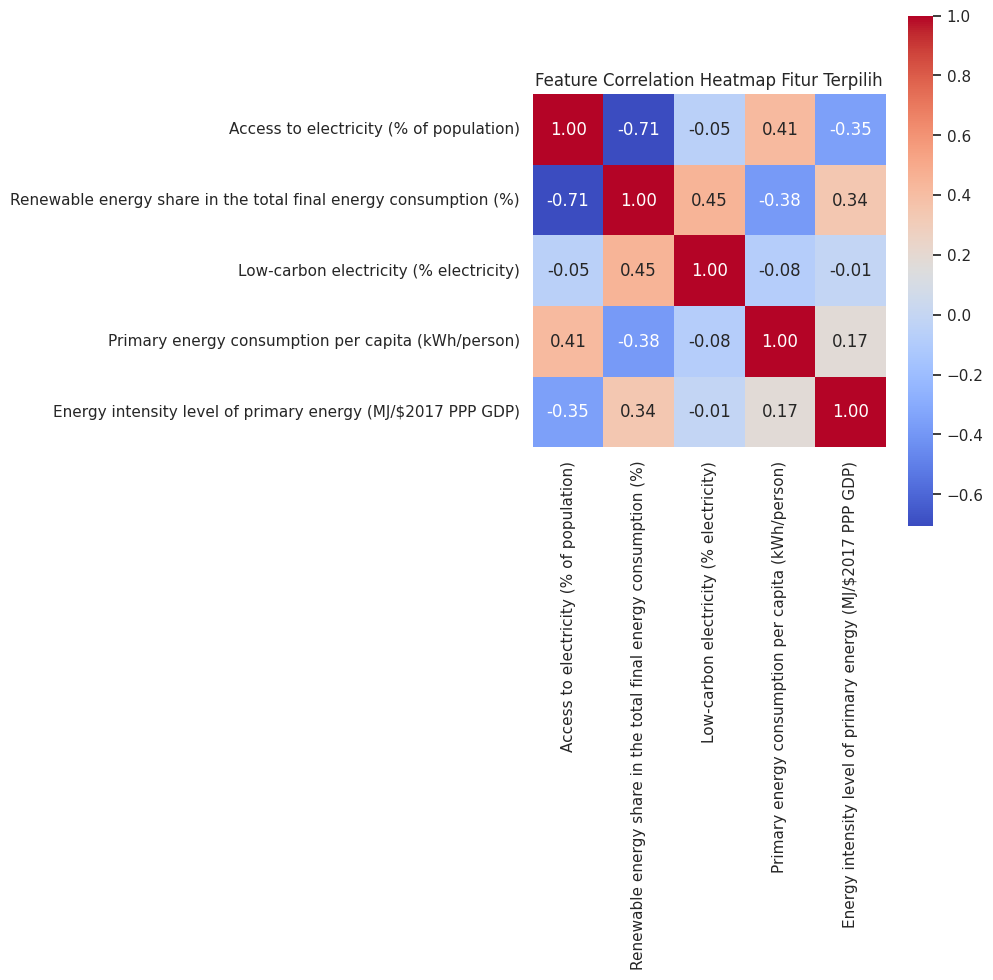

Pasangan fitur dengan korelasi > 0.8:


In [ ]:
plt.figure(figsize=(10, 10))
corr = X.corr()
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            square=True,
            cmap='coolwarm')
plt.title("Feature Correlation Heatmap Fitur Terpilih")
plt.tight_layout()
plt.show()

print('Pasangan fitur dengan korelasi > 0.8:')
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.8:
            print(f'  {corr.columns[i]} <-> {corr.columns[j]}: {corr.iloc[i,j]:.2f}')

Berdasarkan heatmap, terdapat korelasi tinggi antara
`Renewable energy share` dan `Low-carbon electricity` (r = 0.71).
Meskipun berkorelasi, keduanya tetap dipertahankan karena:
- `Renewable energy share` mengukur porsi energi terbarukan dari SELURUH konsumsi energi
- `Low-carbon electricity` mengukur porsi listrik rendah karbon termasuk NUKLIR
Ini membedakan negara nuklir (Prancis) dari negara renewable murni (Norwegia).

### 3.2 Boxplot Fitur Terpilih

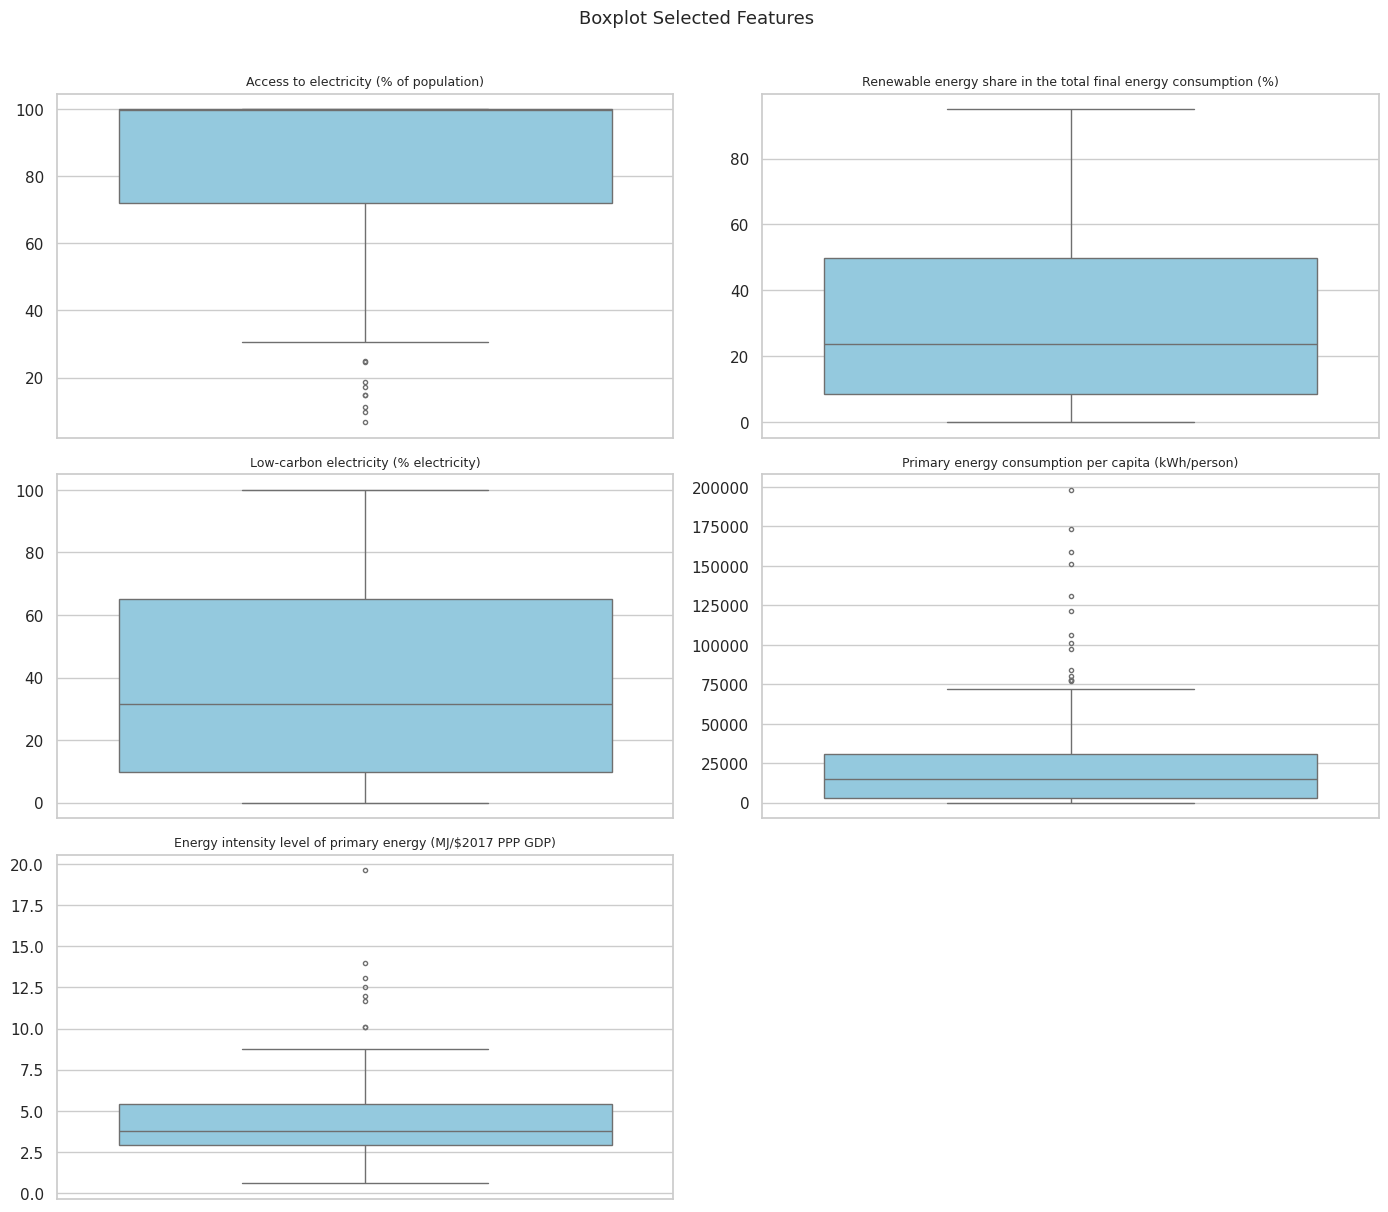

In [ ]:
n_rows = (len(features) + 1) // 2
fig, axes = plt.subplots(nrows=n_rows, ncols=2, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=X[col], ax=axes[i], color='skyblue', flierprops=dict(marker='o', markersize=3))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplot Selected Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4. Preprocessing

### 4.1 Handle Missing Value
missing value akan di isi dengan nilai median karena nilai median lebih robust terhadap outlier

In [ ]:
print('Missing value sebelum imputasi:')
X.isnull().sum()

Missing value sebelum imputasi:


,0
Access to electricity (% of population),1
Renewable energy share in the total final energy consumption (%),1
Low-carbon electricity (% electricity),2
Primary energy consumption per capita (kWh/person),0
Energy intensity level of primary energy (MJ/$2017 PPP GDP),5


In [ ]:
df_clean = df.copy()
df_clean[features] = df_clean[features].fillna(df_clean[features].median())
X = df_clean[features].copy()

print('Missing value setelah imputasi:')
X.isnull().sum()

Missing value setelah imputasi:


,0
Access to electricity (% of population),0
Renewable energy share in the total final energy consumption (%),0
Low-carbon electricity (% electricity),0
Primary energy consumption per capita (kWh/person),0
Energy intensity level of primary energy (MJ/$2017 PPP GDP),0


### 4.2 Handle Outlier (IQR Capping)

Outlier di clip menggunakan batas IQR agar tidak mendominasi centroid K-Means dan linkage Hierarchical.

In [ ]:
X_clipped = X.copy()
clip_bounds = {}

for col in features:
  Q1 = X[col].quantile(0.25)
  Q3 = X[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  X_clipped[col] = X[col].clip(lower=lower, upper=upper)
  clip_bounds[col] = (lower, upper)
  n_cap = ((X[col] < lower) | (X[col] > upper)).sum()
  if n_cap > 0:
      print(f'  {col}: {n_cap} baris di-clip')


  Access to electricity (% of population): 11 baris di-clip
  Primary energy consumption per capita (kWh/person): 14 baris di-clip
  Energy intensity level of primary energy (MJ/$2017 PPP GDP): 8 baris di-clip


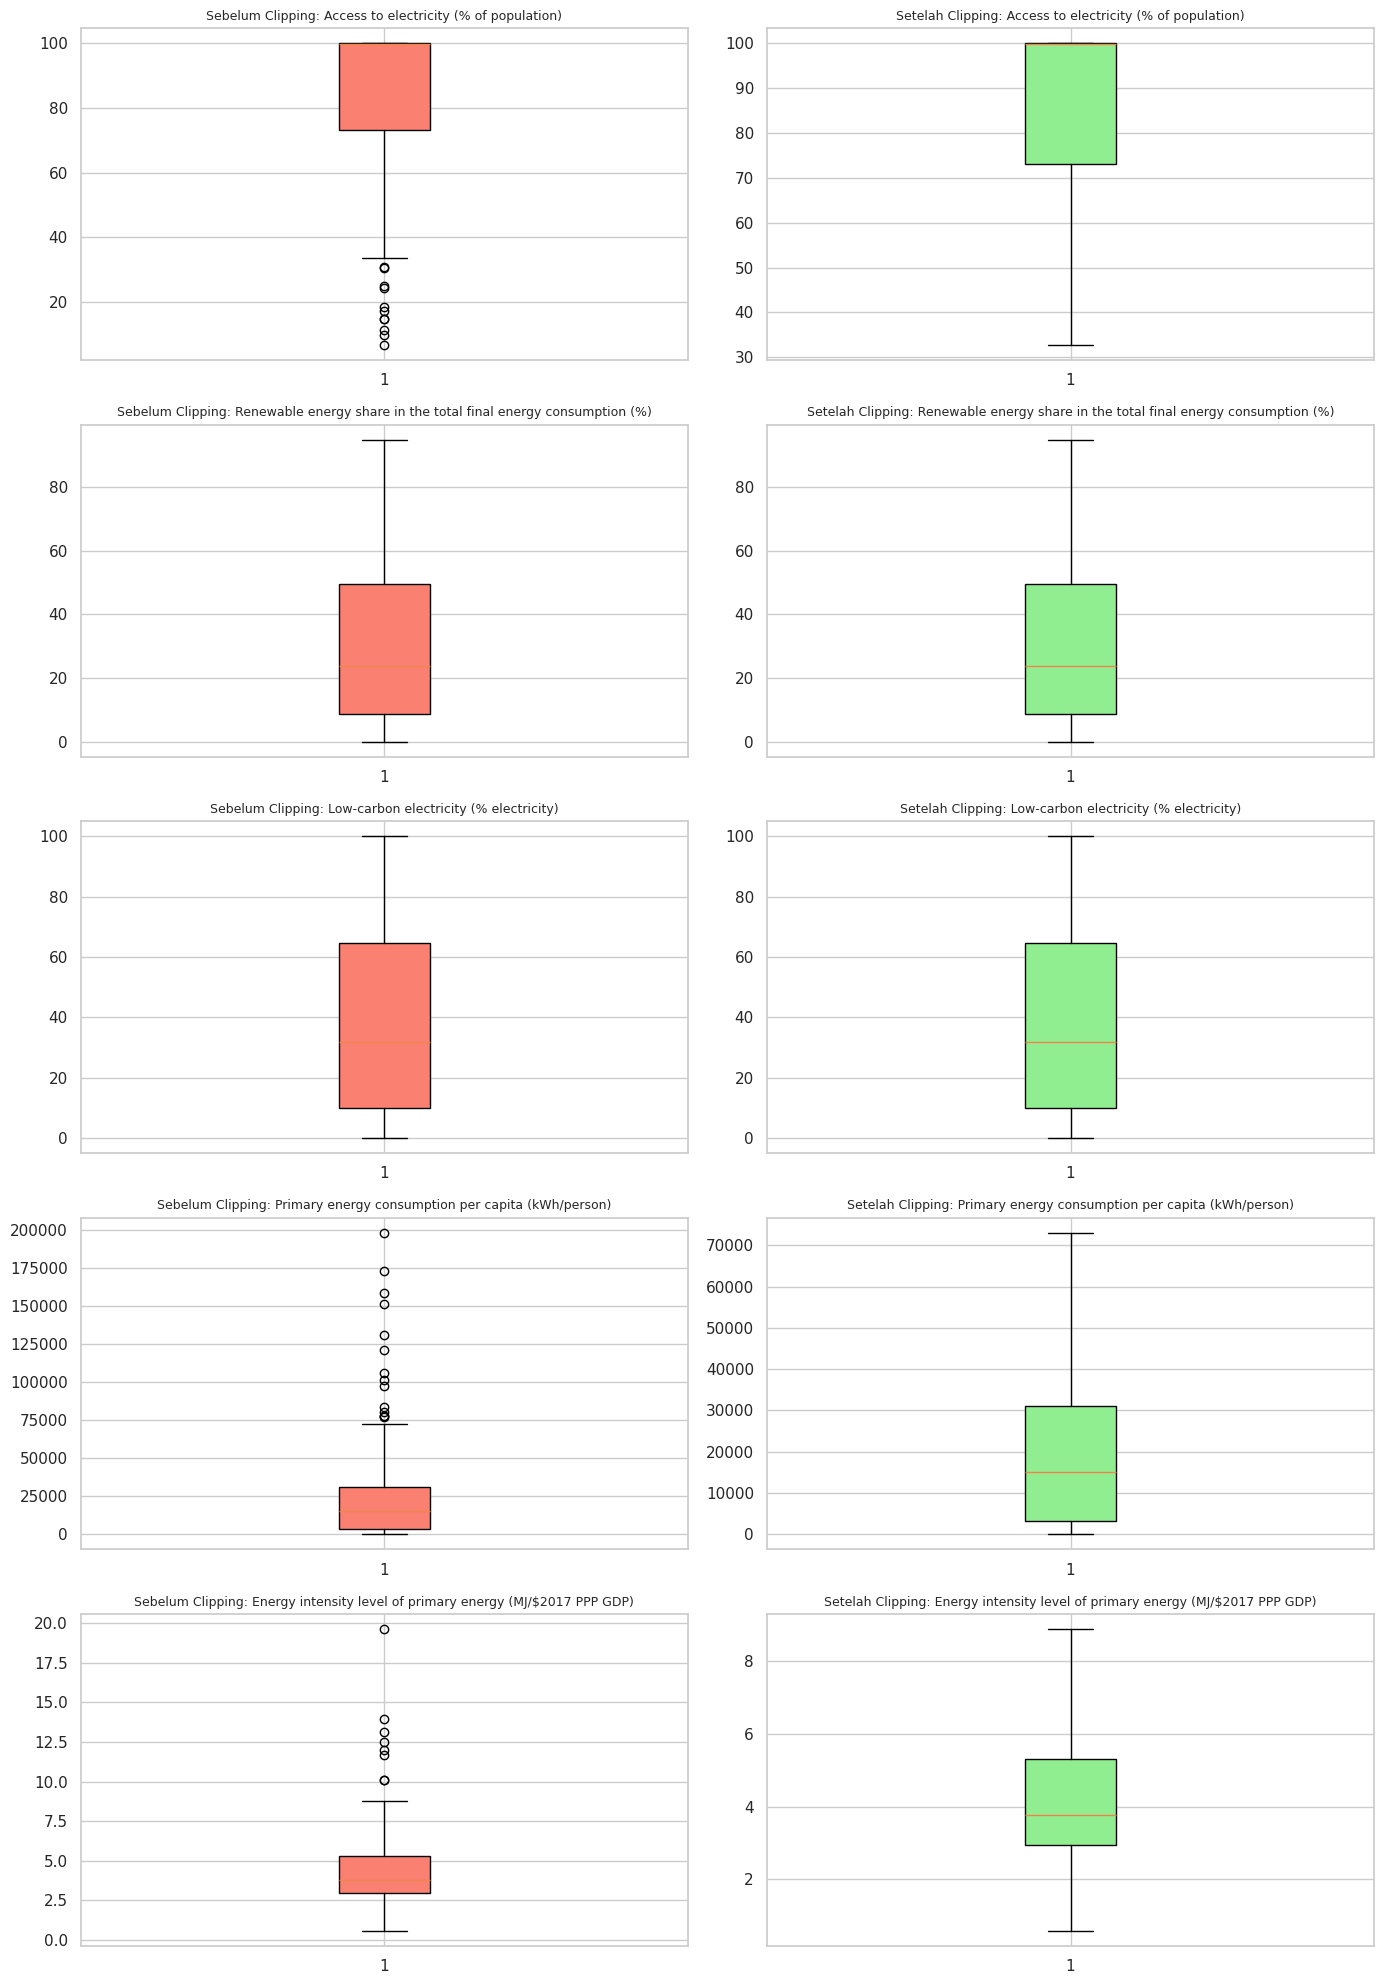

In [ ]:
fig, axes = plt.subplots(len(features), 2, figsize=(14, 4 * len(features)))

for i, col in enumerate(features):
    axes[i, 0].boxplot(X[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='salmon'))
    axes[i, 0].set_title(f'Sebelum Clipping: {col}', fontsize=9)
    axes[i, 1].boxplot(X_clipped[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='lightgreen'))
    axes[i, 1].set_title(f'Setelah Clipping: {col}', fontsize=9)

plt.tight_layout()
plt.show()

### 4.3 Log Transformation

Fitur dengan skewness > 1 ditransformasi dengan `log1p` untuk mendekati distribusi normal.

In [ ]:
log_transformed_features = [col for col in features if X_clipped[col].skew() > 1.0]
print('Fitur yang di-log transform:', log_transformed_features)

X_log = X_clipped.copy()
for col in log_transformed_features:
    X_log[col] = np.log1p(X_log[col])

Fitur yang di-log transform: ['Primary energy consumption per capita (kWh/person)']


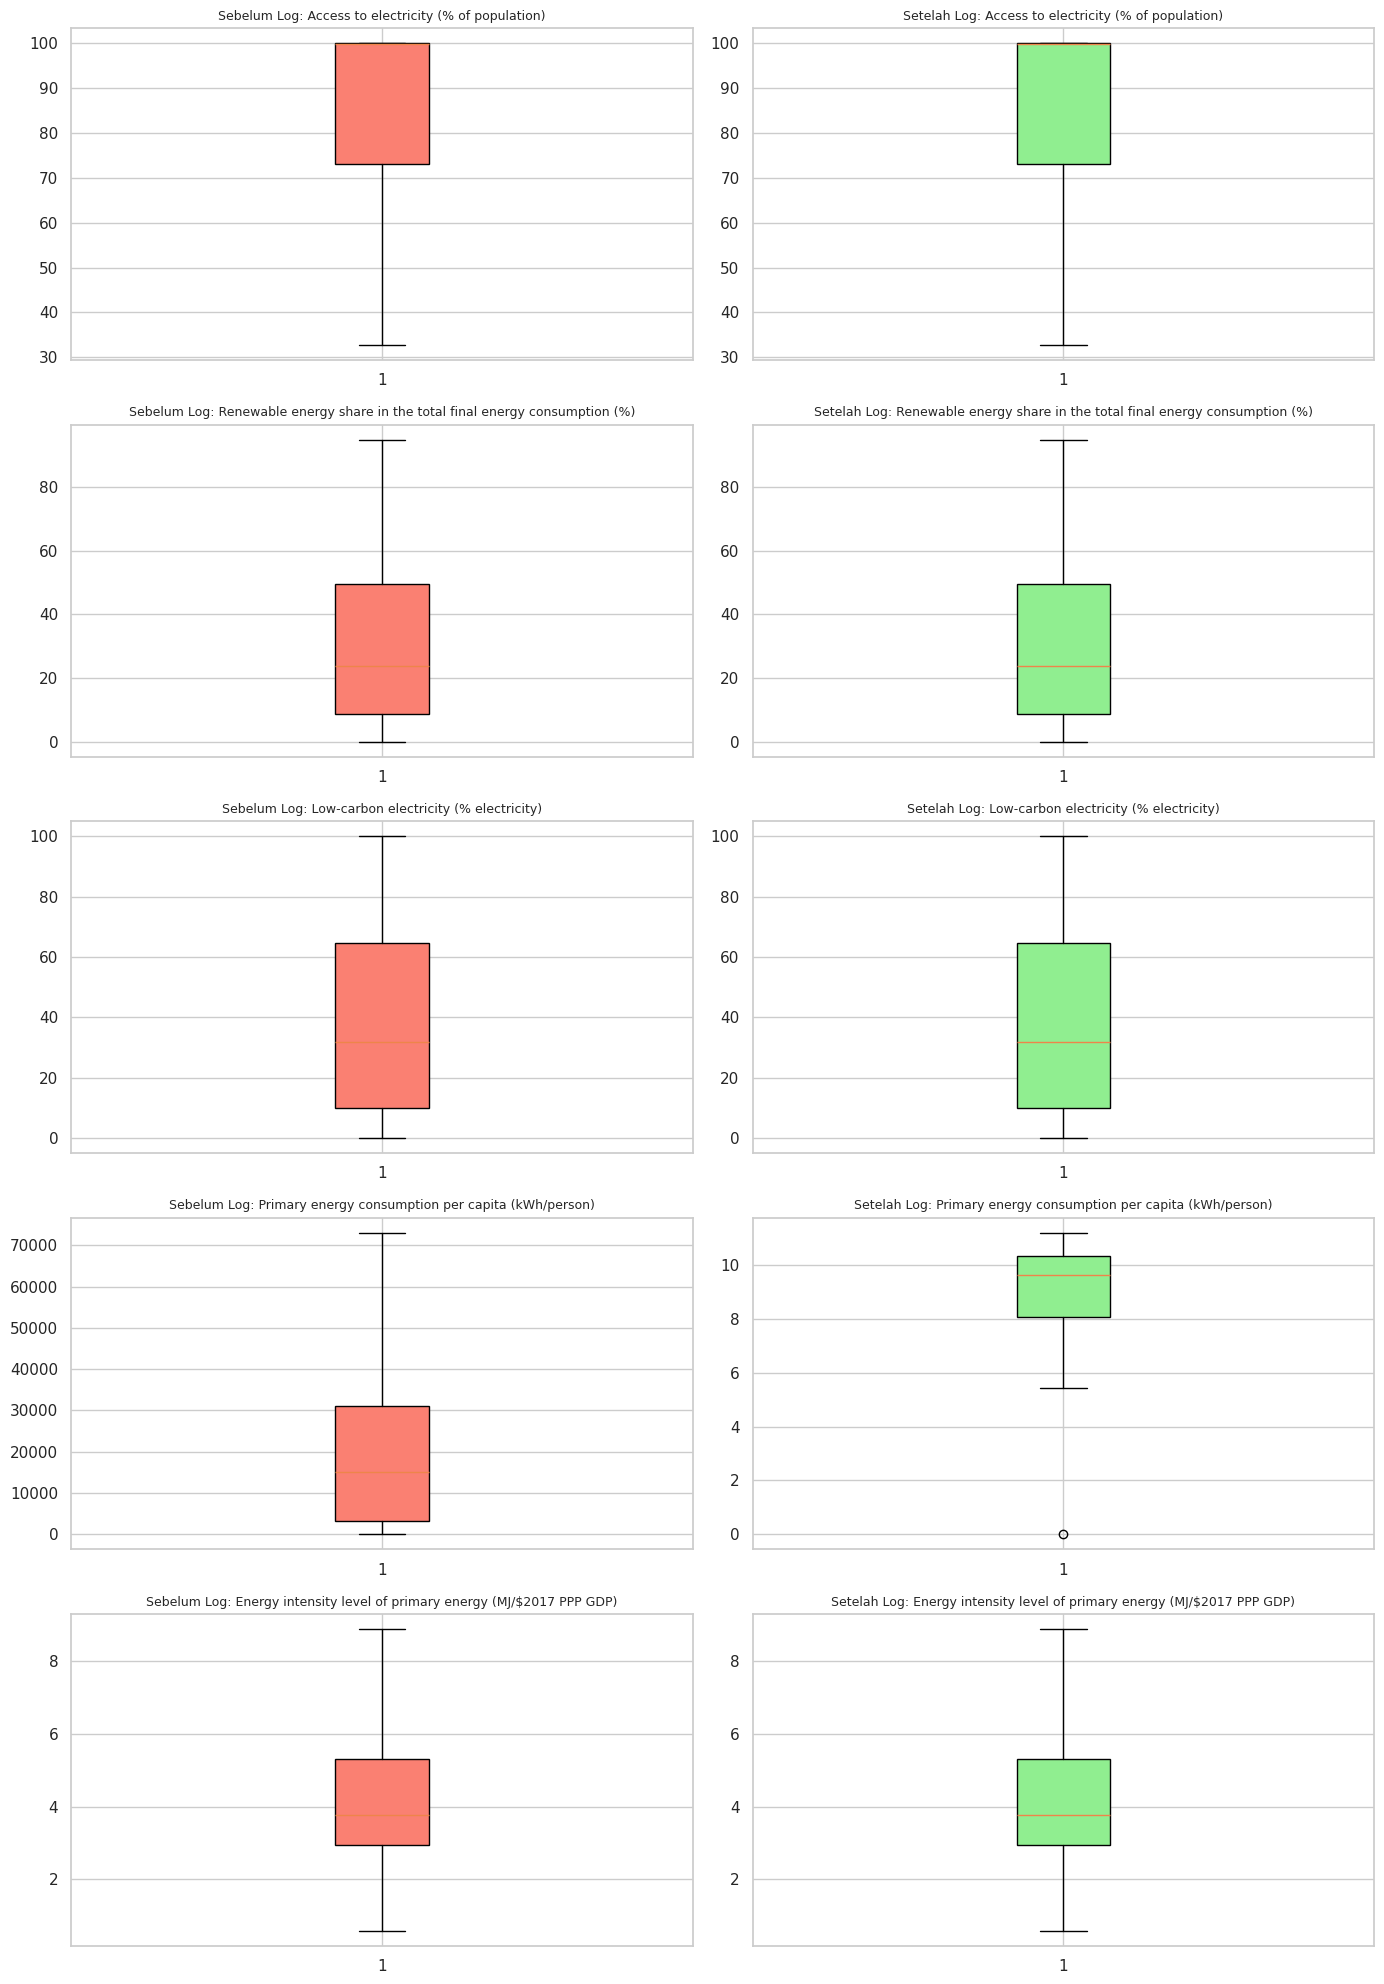

In [ ]:
fig, axes = plt.subplots(len(features), 2, figsize=(14, 4 * len(features)))

for i, col in enumerate(features):
    axes[i, 0].boxplot(X_clipped[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='salmon'))
    axes[i, 0].set_title(f'Sebelum Log: {col}', fontsize=9)
    axes[i, 1].boxplot(X_log[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='lightgreen'))
    axes[i, 1].set_title(f'Setelah Log: {col}', fontsize=9)

plt.tight_layout()
plt.show()

### 4.4 Scaling dengan RobustScaler

`RobustScaler` dipilih karena robust terhadap outlier residual yang mungkin tersisa setelah clipping.

In [ ]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_log)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print('Statistik X_scaled:')
print(X_scaled_df.describe().T[['mean', 'std']].round(4))

Statistik X_scaled:
                                                      mean     std
Access to electricity (% of population)            -0.5185  0.8425
Renewable energy share in the total final energ...  0.1837  0.6783
Low-carbon electricity (% electricity)              0.1363  0.6037
Primary energy consumption per capita (kWh/person) -0.1838  0.7154
Energy intensity level of primary energy (MJ/$2...  0.2416  0.8365


In [ ]:
entity_col = df_clean[['Entity']].copy()
print(f'X_scaled (input clustering): {X_scaled_df.shape}')
print(f'entity_col (identitas negara): {entity_col.shape}')

X_scaled (input clustering): (176, 5)
entity_col (identitas negara): (176, 1)


## 5. Modeling

### 5.1 Menentukan k Optimal (K-Means)

Dua metode digunakan secara bersamaan:
- **Elbow Method** → cari titik tekukan inertia
- **Silhouette Score** → pilih k dengan separasi cluster terbaik

k= 2 | inertia=271.5 | silhouette=0.4657 | DBI=0.9353
k= 3 | inertia=216.8 | silhouette=0.3512 | DBI=1.0405
k= 4 | inertia=179.3 | silhouette=0.3400 | DBI=1.1569
k= 5 | inertia=147.9 | silhouette=0.2979 | DBI=1.0853
k= 6 | inertia=130.6 | silhouette=0.3053 | DBI=1.0794
k= 7 | inertia=115.2 | silhouette=0.3145 | DBI=1.1076
k= 8 | inertia=101.6 | silhouette=0.3196 | DBI=0.9688
k= 9 | inertia=94.6 | silhouette=0.2912 | DBI=1.0068
k=10 | inertia=88.1 | silhouette=0.2967 | DBI=0.9814


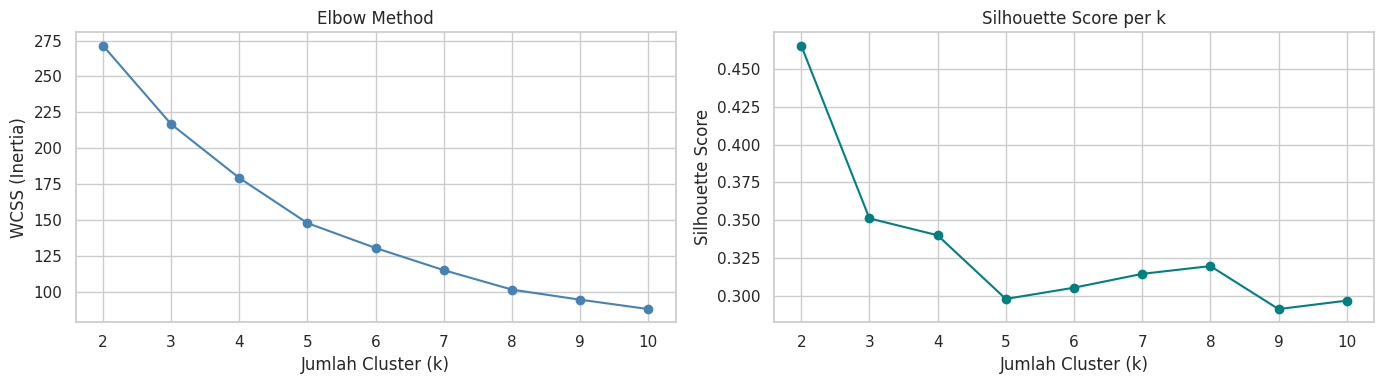


k optimal berdasarkan silhouette tertinggi: 2


In [ ]:
inertia = []
sil_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    dbi = davies_bouldin_score(X_scaled, labels)
    sil_scores.append(sil)
    print(f'k={k:2d} | inertia={km.inertia_:.1f} | silhouette={sil:.4f} | DBI={dbi:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(range(2, 11), inertia, marker='o', color='steelblue')
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].set_title('Elbow Method')

axes[1].plot(range(2, 11), sil_scores, marker='o', color='teal')
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score per k')

plt.tight_layout()
plt.show()

best_k = sil_scores.index(max(sil_scores)) + 2
print(f'\nk optimal berdasarkan silhouette tertinggi: {best_k}')

- k=2 hanya dapat membedakan secara umum
- Untuk 176 negara, 2 kelompok dapat terlalu kasar untuk insight sustainability
- k=3 atau k=4 dipertimbangkan jika elbow method dan silhouette score menunjukkan tekukan di sana
Keputusan: k=2 dipilih karena secara metrik paling valid, dan profil cluster
yang dihasilkan tetap bermakna secara domain

### 5.2 K-Means Clustering

In [ ]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=50)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
kmeans_dbi = davies_bouldin_score(X_scaled, kmeans_labels)
kmeans_chi = calinski_harabasz_score(X_scaled, kmeans_labels)

print(f'K-Means (k={best_k})')
print(f'Silhouette : {kmeans_sil:.4f}')
print(f'DBI: {kmeans_dbi:.4f}')
print(f'CHI: {kmeans_chi:.4f}')

K-Means (k=2)
Silhouette : 0.4657
DBI: 0.9353
CHI: 133.9227


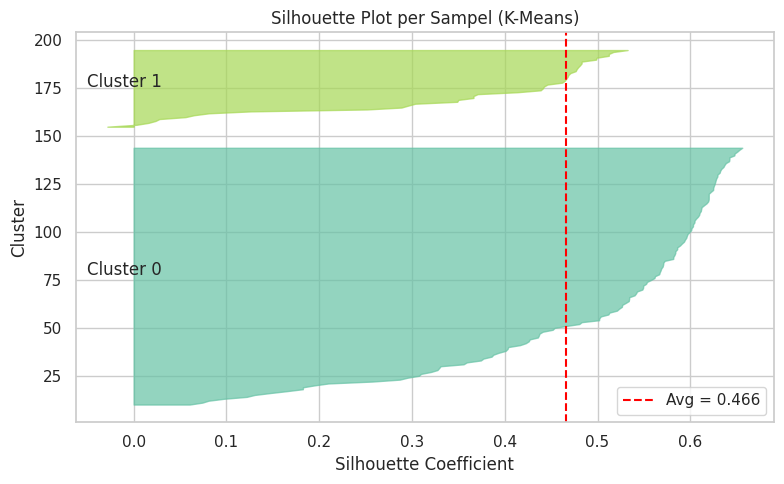

In [ ]:
silhouette_vals = silhouette_samples(X_scaled, kmeans_labels)

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
for i in range(best_k):
    ith_vals = np.sort(silhouette_vals[kmeans_labels == i])
    size = ith_vals.shape[0]
    y_upper = y_lower + size
    color = cm.Set2(i / best_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, f'Cluster {i}')
    y_lower = y_upper + 10

ax.axvline(x=kmeans_sil, color='red', linestyle='--', label=f'Avg = {kmeans_sil:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot per Sampel (K-Means)')
ax.legend()
plt.tight_layout()
plt.show()

### 5.3 Hierarchical Clustering (Ward Linkage)

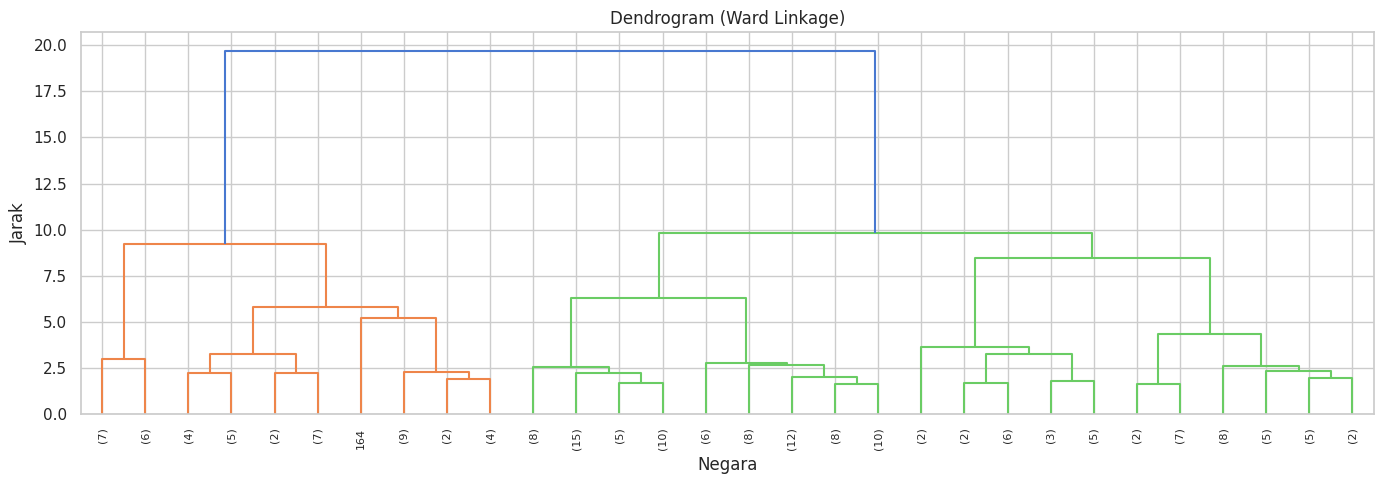

In [ ]:
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8)
plt.title('Dendrogram (Ward Linkage)')
plt.xlabel('Negara')
plt.ylabel('Jarak')
plt.tight_layout()
plt.show()

In [ ]:
hierarchical = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
hier_labels = hierarchical.fit_predict(X_scaled)

hier_sil = silhouette_score(X_scaled, hier_labels)
hier_dbi = davies_bouldin_score(X_scaled, hier_labels)
hier_chi = calinski_harabasz_score(X_scaled, hier_labels)

print(f'Hierarchical (k={best_k})')
print(f'Silhouette : {hier_sil:.4f}')
print(f'DBI: {hier_dbi:.4f}')
print(f'CHI: {hier_chi:.4f}')

Hierarchical (k=2)
Silhouette : 0.4244
DBI: 1.0396
CHI: 118.0326


###5.4 DBSCAN untuk Deteksi Anomali Energi
Metrik DBSCAN tidak sebanding langsung karena noise dieksklusi dan evaluasinya hanya diambil dari non-noise points

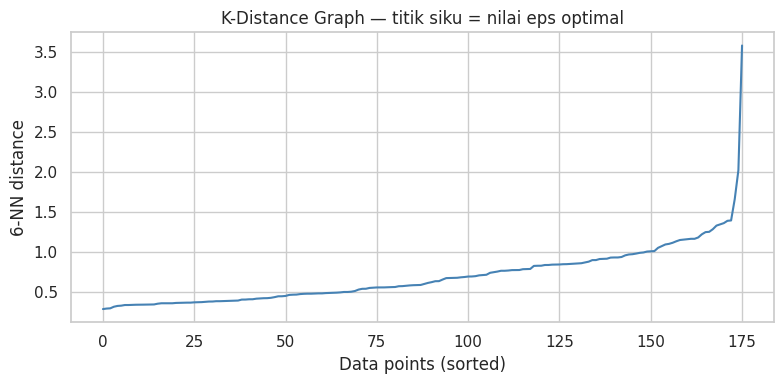

In [ ]:
min_samples = max(5, X_scaled.shape[1] + 1)
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
distances_sorted = np.sort(distances[:, -1])
plt.figure(figsize=(8, 4))
plt.plot(distances_sorted, color='steelblue')
plt.xlabel('Data points (sorted)')
plt.ylabel(f'{min_samples}-NN distance')
plt.title('K-Distance Graph — titik siku = nilai eps optimal')
plt.tight_layout(); plt.show()

In [ ]:
eps_candidates = np.arange(0.3, 3.0, 0.1)
best_eps, best_db_sil, best_db_labels = None, -1, None
for eps in eps_candidates:
  db = DBSCAN(eps=round(eps,1), min_samples=min_samples)
  lab = db.fit_predict(X_scaled)
  n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
  noise_pct = (lab == -1).sum() / len(lab)
  mask = lab != -1
  if n_clusters >= 2 and noise_pct < 0.30:
    sil = silhouette_score(X_scaled[mask], lab[mask])
  if sil > best_db_sil:
    best_db_sil, best_eps, best_db_labels = sil, round(eps,1), lab
print(f'Eps terbaik: {best_eps} | min_samples: {min_samples}')

Eps terbaik: 0.3 | min_samples: 6


In [ ]:
dbscan_labels = best_db_labels
mask = dbscan_labels != -1
n_noise = (~mask).sum()
n_clusters_db = len(set(dbscan_labels)) - 1
db_sil = silhouette_score(X_scaled[mask], dbscan_labels[mask])
db_dbi = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])
db_chi = calinski_harabasz_score(X_scaled[mask], dbscan_labels[mask])
print(f'DBSCAN (eps={best_eps}, min_samples={min_samples})')
print(f'Cluster : {n_clusters_db}')
print(f'Noise : {n_noise} negara ({n_noise/len(dbscan_labels)*100:.1f}%)')
print(f'Silhouette : {db_sil:.4f} (dari {mask.sum()} negara non-noise)')
print(f'DBI : {db_dbi:.4f}')
print(f'CHI : {db_chi:.4f}')

DBSCAN (eps=0.3, min_samples=6)
Cluster : 2
Noise : 163 negara (92.6%)
Silhouette : 0.5417 (dari 13 negara non-noise)
DBI : 0.5886
CHI : 26.7445


In [ ]:
print(f'Negara outlier energi (noise atau negara dengan profil energi yang terlalu unik untuk dikelompokkan):')
noise_countries = df_clean.loc[dbscan_labels == -1, 'Entity'].values
print(noise_countries)

Negara outlier energi (noise atau negara dengan profil energi yang terlalu unik untuk dikelompokkan):
['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Antigua and Barbuda'
 'Argentina' 'Armenia' 'Aruba' 'Australia' 'Austria' 'Azerbaijan'
 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin'
 'Bermuda' 'Bhutan' 'Bosnia and Herzegovina' 'Botswana' 'Brazil'
 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon' 'Canada'
 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia' 'Comoros'
 'Congo' 'Costa Rica' 'Croatia' 'Cuba' 'Czechia' 'Denmark' 'Djibouti'
 'Dominica' 'Dominican Republic' 'Ecuador' 'El Salvador'
 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia' 'Fiji'
 'Finland' 'France' 'French Guiana' 'Gabon' 'Gambia' 'Georgia' 'Germany'
 'Ghana' 'Greece' 'Grenada' 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana'
 'Haiti' 'Honduras' 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iraq'
 'Ireland' 'Italy' 'Jamaica' 'Japan' 'Kazakhstan' 'Kenya' 'Kiribati'
 'Kuwait'

### 5.4 Perbandingan Model

Kriteria pemilihan model terbaik:
- Silhouette : makin tinggi makin baik (maks 1.0)
- DBI : makin rendah makin baik
- CHI : makin tinggi makin baik

In [ ]:
comparison = pd.DataFrame({
    'Model': ['K-Means', 'Hierarchical', 'DBSCAN*'],
    'Silhouette': [round(kmeans_sil, 4), round(hier_sil, 4), round(db_sil, 4)],
    'DBI': [round(kmeans_dbi, 4), round(hier_dbi, 4), round(db_sil, 4)],
    'CHI': [round(kmeans_chi, 4), round(hier_chi, 4), round(db_sil, 4)],
    'Noise (%)': [0, 0, round(n_noise/len(dbscan_labels)*100,1)]
})

def highlight_best(df):
    styled = df.style
    styled = styled.highlight_max(subset=['Silhouette', 'CHI'], color='green')
    styled = styled.highlight_min(subset=['DBI'], color='green')
    return styled

highlight_best(comparison)

,Model,Silhouette,DBI,CHI,Noise (%)
0,K-Means,0.465700,0.935300,133.922700,0.000000
1,Hierarchical,0.424400,1.039600,118.032600,0.000000
2,DBSCAN*,0.541700,0.541700,0.541700,92.600000


### 5.5 Pemilihan Model Final

Berdasarkan tabel perbandingan di atas, K-Means dipilih sebagai model final karena:
- Menggunakan seluruh data negara dalam proses clustering sehingga hasil lebih representatif.
- DBSCAN menganggap 92,6% data sebagai noise, sehingga sebagian besar negara tidak masuk cluster.
- Memiliki DBI lebih rendah (0,9353) dan CHI lebih tinggi (133,9227) dibanding Hierarchical Clustering.
- Menghasilkan cluster yang lebih mudah diinterpretasikan sesuai tujuan penelitian.

## 6. Visualisasi Hasil Clustering

### 6.1 visualisasi t-SNE 2D

t-SNE digunakan untuk memvisualisasikan struktur cluster dalam 2 dimensi.

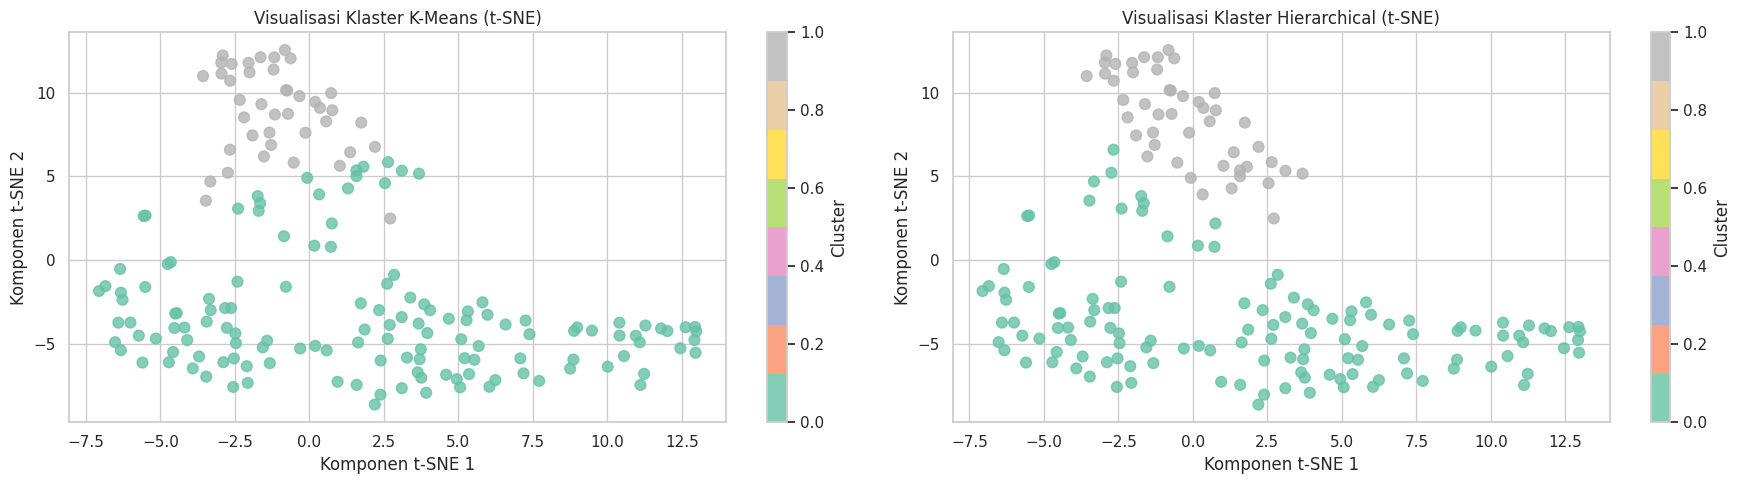

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

cluster_results = [
    (kmeans_labels, 'K-Means'),
    (hier_labels,   'Hierarchical'),
]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, (labels, title) in zip(axes, cluster_results):
    scatter = ax.scatter(
        x=X_tsne[:, 0], y=X_tsne[:, 1],
        c=labels, cmap='Set2', s=60, alpha=0.8
    )
    plt.colorbar(scatter, ax=ax, label='Cluster')
    ax.set_title(f'Visualisasi Klaster {title} (t-SNE)', fontsize=12)
    ax.set_xlabel('Komponen t-SNE 1')
    ax.set_ylabel('Komponen t-SNE 2')

plt.tight_layout()
plt.show()

## 7. Interpretasi Cluster

Profil rata-rata tiap cluster pada skala data asli (sebelum transformasi) untuk kemudahan interpretasi.

In [ ]:
df_result = entity_col.copy()
df_result['cluster_kmeans'] = kmeans_labels
df_result['cluster_hierarchical'] = hier_labels

df_result_feat = df_result.copy()
df_result_feat[features] = X_clipped.values


In [ ]:
profile = df_result_feat.groupby('cluster_kmeans')[features].mean().round(2)
print('Profil rata-rata tiap cluster (Kmeans):')
profile.T

Profil rata-rata tiap cluster (Kmeans):


cluster_kmeans,0,1
Access to electricity (% of population),96.72,49.94
Renewable energy share in the total final energy consumption (%),19.98,68.59
Low-carbon electricity (% electricity),36.35,48.36
Primary energy consumption per capita (kWh/person),27857.69,1976.34
Energy intensity level of primary energy (MJ/$2017 PPP GDP),3.91,5.77


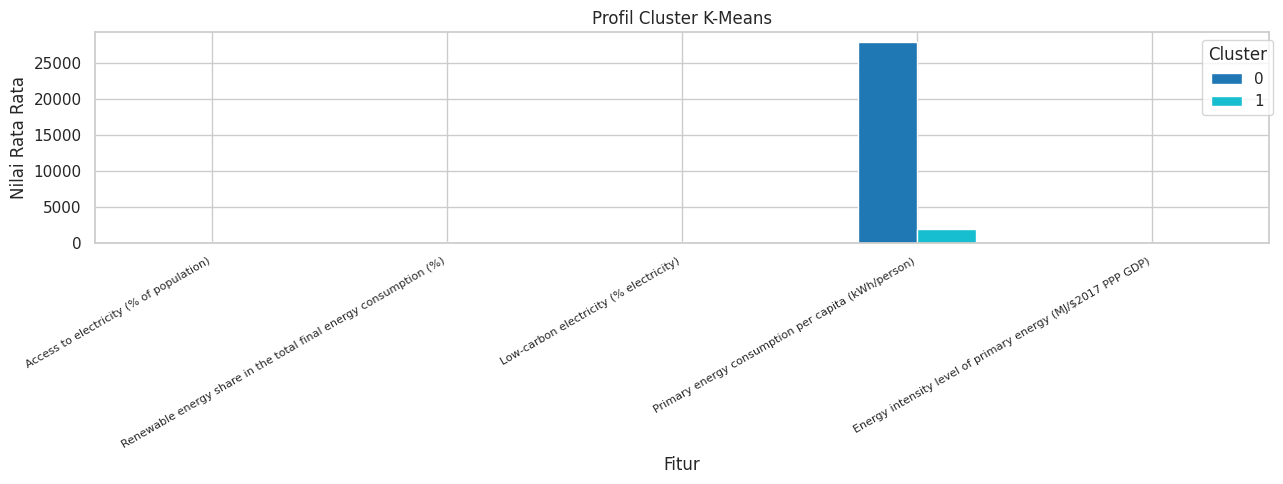

In [ ]:
profile.T.plot(kind='bar', figsize=(13, 5), colormap='tab10', edgecolor='white')
plt.title('Profil Cluster K-Means', fontsize=12)
plt.xlabel('Fitur')
plt.ylabel('Nilai Rata Rata')
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.legend(title='Cluster', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

In [ ]:
profile_hier = df_result_feat.groupby('cluster_hierarchical')[features].mean().round(2)
print('Profil rata-rata tiap cluster (Hierarchical):')
profile_hier.T

Profil rata-rata tiap cluster (Hierarchical):


cluster_hierarchical,0,1
Access to electricity (% of population),98.19,51.87
Renewable energy share in the total final energy consumption (%),20.88,59.93
Low-carbon electricity (% electricity),39.18,39.07
Primary energy consumption per capita (kWh/person),28921.06,2361.74
Energy intensity level of primary energy (MJ/$2017 PPP GDP),4.01,5.27


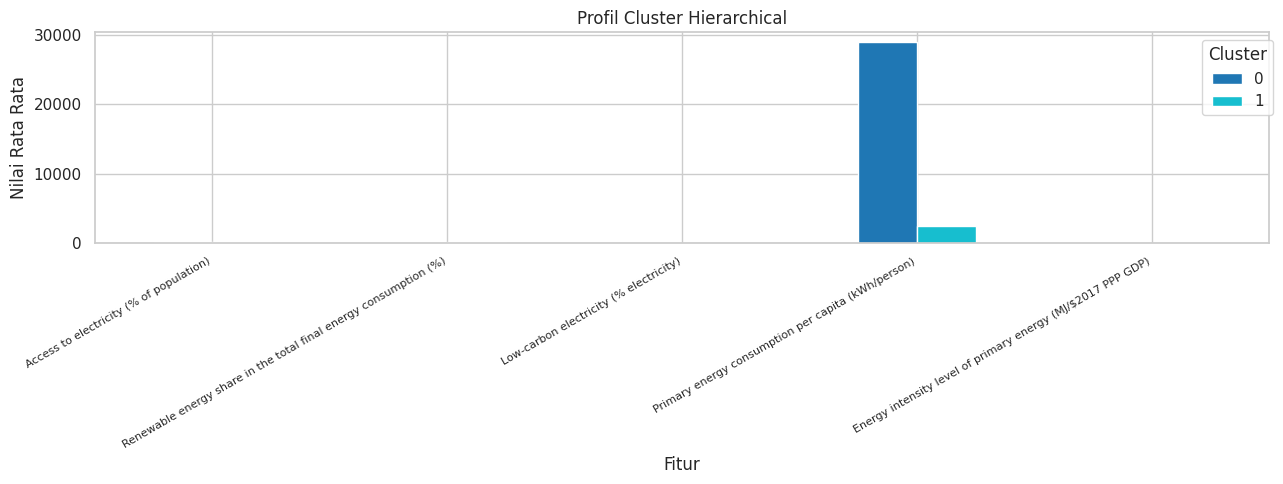

In [ ]:
profile_hier.T.plot(kind='bar', figsize=(13, 5), colormap='tab10', edgecolor='white')
plt.title('Profil Cluster Hierarchical', fontsize=12)
plt.xlabel('Fitur')
plt.ylabel('Nilai Rata Rata')
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.legend(title='Cluster', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

In [ ]:
cluster_names = {
    0: 'Akses Listrik dan Konsumsi Energi Tinggi dengan Efisiensi Energi Lebih Baik',
    1: 'Akses Listrik dan Konsumsi Energi Rendah dengan Energi Terbarukan Berbasis Biomassa'
}

df_result['cluster_label']      = df_result['cluster_kmeans'].map(cluster_names)
df_result_feat['cluster_label'] = df_result_feat['cluster_kmeans'].map(cluster_names)

In [ ]:
print('Daftar negara per cluster')
for c, name in cluster_names.items():
  negara = df_result[df_result['cluster_kmeans'] == c]['Entity'].values
  print(f"\nCluster {c} / {name}: {len(negara)} negara")
  print(df_result[df_result['cluster_kmeans'] == c]['Entity'].unique())

Daftar negara per cluster

Cluster 0 / Akses Listrik dan Konsumsi Energi Tinggi dengan Efisiensi Energi Lebih Baik: 135 negara
['Afghanistan' 'Albania' 'Algeria' 'Antigua and Barbuda' 'Argentina'
 'Armenia' 'Aruba' 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain'
 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Bermuda' 'Bhutan'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Bulgaria' 'Cambodia'
 'Canada' 'Cayman Islands' 'Chile' 'China' 'Colombia' 'Comoros'
 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus' 'Czechia' 'Denmark' 'Djibouti'
 'Dominica' 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador'
 'Equatorial Guinea' 'Estonia' 'Fiji' 'Finland' 'France' 'French Guiana'
 'Georgia' 'Germany' 'Ghana' 'Greece' 'Grenada' 'Guatemala' 'Guyana'
 'Honduras' 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iraq' 'Ireland'
 'Israel' 'Italy' 'Jamaica' 'Japan' 'Jordan' 'Kazakhstan' 'Kiribati'
 'Kuwait' 'Kyrgyzstan' 'Latvia' 'Lebanon' 'Libya' 'Lithuania' 'Luxembourg'
 'Malaysia' 'Maldives' 'Malta' 'Ma

## 8. Pipeline Preprocessing

In [ ]:
# Simpan referensi yang dibutuhkan pipeline
_clip_bounds           = clip_bounds.copy()
_log_transformed_feats = log_transformed_features.copy()
_features              = features.copy()

def clip_transform(X):
  X = X.copy()
  for col, (lo, hi) in _clip_bounds.items():
      X[col] = X[col].clip(lo, hi)
  return X

def log_transform(X):
  X = X.copy()
  for col in _log_transformed_feats:
      X[col] = np.log1p(X[col])
  return X

preprocessing_pipeline = Pipeline([
  ('clip', FunctionTransformer(clip_transform, validate=False)),
  ('log',  FunctionTransformer(log_transform,  validate=False)),
  ('scale', RobustScaler()),
])

preprocessing_pipeline.fit(X)

X_pipeline_out = preprocessing_pipeline.transform(X)
print(f'Pipeline output shape: {X_pipeline_out.shape}')
print(f'Max perbedaan vs X_scaled asli: {np.abs(X_pipeline_out - X_scaled).max():.2e}')
print('Pipeline verified OK.' if np.allclose(X_pipeline_out, X_scaled) else 'PERINGATAN: ada perbedaan!')

Pipeline output shape: (176, 5)
Max perbedaan vs X_scaled asli: 0.00e+00
Pipeline verified OK.


## 9. Prediksi Cluster Data Baru

In [ ]:
def predict_cluster(fitur_dict: dict) -> dict:
  missing_keys = [f for f in _features if f not in fitur_dict]
  if missing_keys:
    raise ValueError(f'Fitur berikut tidak ada di input: {missing_keys}')
  X_new = pd.DataFrame([fitur_dict])[_features]

  X_new_scaled = preprocessing_pipeline.transform(X_new)

  cluster_id = kmeans.predict(X_new_scaled)[0]
  distances  = kmeans.transform(X_new_scaled)[0]

  profil = df_result_feat.groupby('cluster_kmeans')[_features].mean().round(2)

  return {
    'cluster'              : int(cluster_id),
    'distances_to_centers' : {f'Cluster {i}': round(float(d), 4) for i, d in enumerate(distances)},
    'cluster_label' : cluster_names[int(cluster_id)],
    'profil_cluster'       : profil.loc[cluster_id].to_dict()
  }

In [ ]:
data_baru = {
    'Access to electricity (% of population)': 98,
    'Renewable energy share in the total final energy consumption (%)': 20,
    'Low-carbon electricity (% electricity)': 35,
    'Primary energy consumption per capita (kWh/person)': 25000,
    'Energy intensity level of primary energy (MJ/$2017 PPP GDP)': 4,
    'gdp_per_capita': 200
}

hasil = predict_cluster(data_baru)
print(f"Cluster : {hasil['cluster']} / {cluster_names[hasil['cluster']]}")

print(f"\nJarak ke setiap centroid:")
for k, v in hasil['distances_to_centers'].items():
    print(f"  {k}: {v}")
print(f"\nProfil rata-rata Cluster {hasil['cluster']}:")
for feat, val in hasil['profil_cluster'].items():
    print(f"  {feat}: {val}")

Cluster : 0 / Akses Listrik dan Konsumsi Energi Tinggi dengan Efisiensi Energi Lebih Baik

Jarak ke setiap centroid:
  Cluster 0: 0.1348
  Cluster 1: 2.66

Profil rata-rata Cluster 0:
  Access to electricity (% of population): 96.72
  Renewable energy share in the total final energy consumption (%): 19.98
  Low-carbon electricity (% electricity): 36.35
  Primary energy consumption per capita (kWh/person): 27857.69
  Energy intensity level of primary energy (MJ/$2017 PPP GDP): 3.91


## 10. Simpan Model & Artefak

In [ ]:
joblib.dump(kmeans,'kmeans_model.pkl')
joblib.dump(preprocessing_pipeline,'preprocessing_pipeline.pkl')
joblib.dump(log_transformed_features,'log_transformed_features.pkl')
joblib.dump(clip_bounds,'clip_bounds.pkl')
joblib.dump(features,'features.pkl')
joblib.dump(df_result_feat,'cluster_profiles.pkl')
joblib.dump(cluster_names, 'cluster_names.pkl')
joblib.dump(noise_countries, 'noise_countries.pkl')
joblib.dump(X_log, 'X_log.pkl')

['X_log.pkl']

## 11. Kesimpulan

**Hasil utama:**
- K optimal yang dipilih: k=2, berdasarkan Silhouette Score tertinggi
- Model terbaik: K-Means (Silhouette: 0.465700, DBI: 0.935300, CHI: 133.922700)
- Cluster 0 atau Negara Tinggi Konsumsi dengan Rendah Terbarukan:
  didominasi negara maju dengan akses listrik sekitar 97%, konsumsi 27.857 kWh/kapita,
  namun renewable share hanya 20%
- Cluster 1 atau Negara Rendah Konsumsi dengan Dominan Terbarukan:
  didominasi negara berkembang dengan akses listrik sekitar 50%, konsumsi sangat rendah
  1.976 kWh/kapita, namun renewable share mencapai 69%

**Insight:** Cluster 1 memiliki renewable share tinggi bukan karena
transisi energi aktif, tetapi karena konsumsi energi total yang sangat rendah atau banyak biomassa tradisional. Ini berbeda maknanya dengan "hijau" dalam konteks
negara maju.

**Keterbatasan:**
- Hanya 2 cluster yang terbentuk
- Data agregasi 3 tahun terakhir mungkin tidak merepresentasikan negara dengan data tidak lengkap
- Silhouette 0.465700 menunjukkan ada tumpang tindih antar cluster yang wajar
  untuk data geopolitik

**Saran pengembangan:**
- Tambahkan fitur `CO2 emissions per capita` untuk dimensi dampak lingkungan
- Terapkan model ke data terbaru untuk monitoring perubahan posisi tiap negara dari waktu ke waktu